In [4]:
import pandas as pd
import numpy as np

# Load the data
# Load the data using read_csv instead
df = pd.read_csv("Flights_2022_sampled_1.8M.csv")

# Inspect the first few rows and column types
print(df.head())
print(df.info())

C:\Users\jiyaa\AppData\Local\Temp\ipykernel_27064\3557843951.py:6: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Flights_2022_sampled_1.8M.csv")


   Month  DayofMonth  DayOfWeek  FlightDate Marketing_Airline_Network  \
0      1          30          7  2022-01-30                        WN   
1      1          20          4  2022-01-20                        F9   
2      1          28          5  2022-01-28                        AA   
3      1           3          1  2022-01-03                        F9   
4      1           9          7  2022-01-09                        AA   

  Operated_or_Branded_Code_Share_Partners  DOT_ID_Marketing_Airline  \
0                                      WN                     19393   
1                                      F9                     20436   
2                            AA_CODESHARE                     19805   
3                                      F9                     20436   
4                            AA_CODESHARE                     19805   

  IATA_Code_Marketing_Airline  Flight_Number_Marketing_Airline  \
0                          WN                             2074   
1 

In [5]:
# This prints the name of column 51 and its unique values
print("Column 51 name:", df.columns[51])
print(df.iloc[:, 51].unique()[:20])  # Shows the first 20 unique values

Column 51 name: CancellationCode
[nan 'B' 'A' 'D' 'C']


In [6]:
# Run this right before building a model to remove the original text column....this is for cancellation code column
#df.drop(columns=['CancellationCode'], inplace=True)

In [7]:
df['FlightDate'] = pd.to_datetime(df['FlightDate']) #tell to treat dates as actual dates not strings

In [8]:
#Extract Time based Features
# 1. Day of the week (0 = Monday, 6 = Sunday)
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek

# 2. Is it the weekend? (Fridays and Sundays are notoriously chaotic for travel)
df['Is_Weekend'] = df['FlightDate'].dt.dayofweek.isin([4, 5, 6]).astype(int)

# 3. Month of the year (1 to 12)
df['Month'] = df['FlightDate'].dt.month

# 4. Day of the month (1 to 31) - helps capture start/end of month travel spikes
df['DayOfMonth'] = df['FlightDate'].dt.day

In [9]:
df.head()

,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,...,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DivAirportLandings,Duplicate,Is_Weekend,DayOfMonth
0,1,30,6,2022-01-30,WN,WN,19393,WN,2074,WN,...,2,0.0,0.0,0.0,0.0,0.0,0,N,1,30
1,1,20,3,2022-01-20,F9,F9,20436,F9,538,F9,...,6,0.0,0.0,0.0,0.0,0.0,0,N,0,20
2,1,28,4,2022-01-28,AA,AA_CODESHARE,19805,AA,4753,YX,...,3,0.0,0.0,0.0,0.0,0.0,0,N,1,28
3,1,3,0,2022-01-03,F9,F9,20436,F9,1118,F9,...,4,17.0,0.0,2.0,0.0,0.0,0,N,0,3
4,1,9,6,2022-01-09,AA,AA_CODESHARE,19805,AA,3927,MQ,...,3,0.0,0.0,0.0,0.0,0.0,0,N,1,9


In [10]:
# Grouping into explicit seasons
# 1 = Winter (Dec-Feb), 2 = Spring (Mar-May), 3 = Summer (Jun-Aug), 4 = Fall (Sep-Nov)
df['Season'] = df['Month'].apply(lambda x: 1 if x in [12, 1, 2] else (2 if x in [3, 4, 5] else (3 if x in [6, 7, 8] else 4)))

In [15]:
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [17]:
df[['Month', 'Month_sin', 'Month_cos']].head()

,Month,Month_sin,Month_cos
0,1,0.5,0.866025
1,1,0.5,0.866025
2,1,0.5,0.866025
3,1,0.5,0.866025
4,1,0.5,0.866025


In [18]:
#Create the target variable
df['Is_Delayed'] = (df['ArrDelay'] > 15).astype(int)

In [20]:
df.columns.tolist()

['Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Marketing_Airline_Network',
 'Operated_or_Branded_Code_Share_Partners',
 'DOT_ID_Marketing_Airline',
 'IATA_Code_Marketing_Airline',
 'Flight_Number_Marketing_Airline',
 'Operating_Airline ',
 'DOT_ID_Operating_Airline',
 'IATA_Code_Operating_Airline',
 'Tail_Number',
 'Flight_Number_Operating_Airline',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'DepTimeBlk',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrivalDelayGroups',
 'ArrTimeBlk',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'C

In [21]:
#Calculate each airline's historical delay rate
airline_delay_prob = df.groupby('Operating_Airline ')['Is_Delayed'].mean()

In [23]:
#Map the delay rate back to every row
df['Airline_Delay_Risk'] = df['Operating_Airline '].map(airline_delay_prob)

In [24]:
#For Airports 
origin_delay_prob = df.groupby('Origin')['Is_Delayed'].mean()
dest_delay_prob = df.groupby('Dest')['Is_Delayed'].mean()

df['Origin_Airport_Risk'] = df['Origin'].map(origin_delay_prob)
df['Dest_Airport_Risk'] = df['Dest'].map(dest_delay_prob)

In [25]:
df.head()

,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,...,Duplicate,Is_Weekend,DayOfMonth,Season,Month_sin,Month_cos,Is_Delayed,Airline_Delay_Risk,Origin_Airport_Risk,Dest_Airport_Risk
0,1,30,6,2022-01-30,WN,WN,19393,WN,2074,WN,...,N,1,30,1,0.5,0.866025,0,0.209769,0.234168,0.185950
1,1,20,3,2022-01-20,F9,F9,20436,F9,538,F9,...,N,0,20,1,0.5,0.866025,0,0.297672,0.249121,0.194257
2,1,28,4,2022-01-28,AA,AA_CODESHARE,19805,AA,4753,YX,...,N,1,28,1,0.5,0.866025,0,0.173343,0.158124,0.237339
3,1,3,0,2022-01-03,F9,F9,20436,F9,1118,F9,...,N,0,3,1,0.5,0.866025,1,0.297672,0.247384,0.191460
4,1,9,6,2022-01-09,AA,AA_CODESHARE,19805,AA,3927,MQ,...,N,1,9,1,0.5,0.866025,0,0.143840,0.158124,0.169625


In [26]:
# Filter and show columns related to times, delays, and taxi metrics
time_delay_cols = [c for c in df.columns if any(x in c.lower() for x in ['time', 'delay', 'taxi', 'arr', 'dep'])]
print(time_delay_cols)

['CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'ArrDelayMinutes', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'Is_Delayed', 'Airline_Delay_Risk']


In [27]:
#Convert Scheduled Times to Clean Numeric Features
# Convert Scheduled Departure and Arrival to Minutes Since Midnight
df['CRSDepTime_Mins'] = (df['CRSDepTime'] // 100) * 60 + (df['CRSDepTime'] % 100)
df['CRSArrTime_Mins'] = (df['CRSArrTime'] // 100) * 60 + (df['CRSArrTime'] % 100)

# Extract the raw hour (0 to 23) to capture peak airport rush hours
df['DepHour'] = df['CRSDepTime'] // 100

In [28]:
# 1. Total Taxi Time (Total minutes spent driving on the ground)
df['Total_Taxi_Time'] = df['TaxiOut'] + df['TaxiIn']

# 2. Ground-to-Air Ratio
# High ratio means a huge chunk of the trip was wasted crawling on the ground
df['Ground_Time_Ratio'] = df['Total_Taxi_Time'] / df['ActualElapsedTime']

In [29]:
df['Time_Made_Up'] = df['DepDelay'] - df['ArrDelay']

In [30]:
df.head()

,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,...,Is_Delayed,Airline_Delay_Risk,Origin_Airport_Risk,Dest_Airport_Risk,CRSDepTime_Mins,CRSArrTime_Mins,DepHour,Total_Taxi_Time,Ground_Time_Ratio,Time_Made_Up
0,1,30,6,2022-01-30,WN,WN,19393,WN,2074,WN,...,0,0.209769,0.234168,0.185950,1015,1085,16,13.0,0.209677,8.0
1,1,20,3,2022-01-20,F9,F9,20436,F9,538,F9,...,0,0.297672,0.249121,0.194257,1004,1319,16,25.0,0.128205,0.0
2,1,28,4,2022-01-28,AA,AA_CODESHARE,19805,AA,4753,YX,...,0,0.173343,0.158124,0.237339,420,540,7,36.0,0.268657,-14.0
3,1,3,0,2022-01-03,F9,F9,20436,F9,1118,F9,...,1,0.297672,0.247384,0.191460,867,1016,14,32.0,0.211921,-2.0
4,1,9,6,2022-01-09,AA,AA_CODESHARE,19805,AA,3927,MQ,...,0,0.143840,0.158124,0.169625,777,870,12,32.0,0.228571,13.0


In [32]:
# List of original text/raw columns we no longer need because we engineered superior versions
columns_to_drop = [
    'CancellationCode', 
    'FlightDate', 
    'Operating_Airline ', 
    'Origin', 
    'Dest',
    'Marketing_Airline_Network',
    'Operated_or_Branded_Code_Share_Partners',
    'IATA_Code_Marketing_Airline',
    'DepTimeBlk',
    'ArrTimeBlk'
]

# Drop them safely
df_final = df.drop(columns=columns_to_drop, errors='ignore')

print("New final shape:", df_final.shape)

New final shape: (593022, 71)


In [36]:
df_final.shape

(593022, 71)

In [ ]:
# Dimensionality reduction

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Select only your numeric and encoded columns
# Drop any target variables like 'DepDelay' if you want to see pure operational clustering
X_numeric = df_final.select_dtypes(include=[np.number]).fillna(0)

# 2. Standardize features so high values (like Distance) don't dominate small values (like encoded Risk)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# 3. Apply PCA to compress all columns into 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Save into a clean visualization dataframe
df_pca = pd.DataFrame(data=X_pca, columns=['Component_1', 'Component_2'])

# Add back a raw column to use as a visual color tag (e.g., actual delay minutes)
df_pca['DepDelay'] = df_final['DepDelay'].values

print("Dataset successfully reduced!")
print(f"Original shape: {X_numeric.shape} -> Reduced visual shape: {df_pca.shape}")
print(f"Variance explained by these 2 dimensions: {round(pca.explained_variance_ratio_.sum() * 100, 2)}%")

Dataset successfully reduced!
Original shape: (593022, 60) -> Reduced visual shape: (593022, 3)
Variance explained by these 2 dimensions: 25.53%


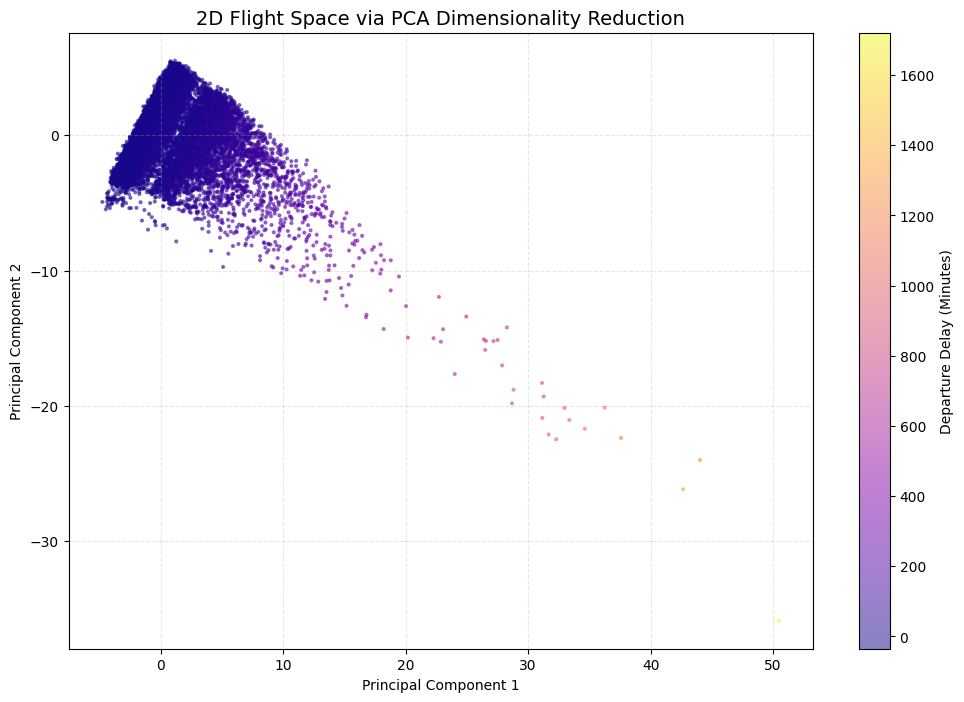

In [38]:
# Sample for a clean, fast-rendering plot
df_vis_sample = df_pca.sample(n=25000, random_state=42)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_vis_sample['Component_1'], 
    df_vis_sample['Component_2'], 
    c=df_vis_sample['DepDelay'], 
    cmap='plasma', 
    alpha=0.5, 
    s=4
)

# Customize the chart
plt.colorbar(scatter, label='Departure Delay (Minutes)')
plt.title('2D Flight Space via PCA Dimensionality Reduction', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


In [39]:
# Run this cell inside your VS Code Notebook
df_final.to_csv('final_engineered_flight_data.csv', index=False)
print("Data successfully saved to your local VS Code workspace folder!")

Data successfully saved to your local VS Code workspace folder!
